# Bayesian Hyperparameter Inference With Monte Carlo Sampling

This notebook explores how Monte Carlo methods can estimate uncertain hyperparameters in a Bayesian RBF regression model. Starting from synthetic noisy observations, it studies the posterior over the prior precision $\alpha$ and basis width $r$, estimates expectations with importance sampling, and then uses Metropolis MCMC to infer $r$, the noise scale $\sigma$, and ultimately the model weights.

The emphasis is on practical inference: proposal distributions are compared through convergence and acceptance diagnostics, and the final samples are used to construct a predictive model.

**Workflow:**

1. Generate a reproducible regression data set and RBF design matrix.
2. Evaluate the hyperparameter posterior over a logarithmic grid.
3. Estimate $\langle r \rangle$ with several importance proposals.
4. Compare Metropolis proposals and inspect their diagnostics.
5. Extend the sampler to infer $\sigma$ and all model unknowns.

The helper module `setup_cw2.py` provides the synthetic data, RBF basis, plotting, and table utilities.

## Context And Reproducibility

This notebook is the first stage of a broader Bayesian modelling workflow. It focuses on custom Monte Carlo algorithms and keeps the sampling calculations visible so their behaviour can be inspected directly.

The random-number generators are seeded in the experiment cells. Running the notebook from `Coursework_2/` makes the local helper module available and reproduces the same data and diagnostics.

## Notebook Guide

The notebook moves from a low-dimensional visual inspection of the posterior to increasingly realistic sampling problems. Each section introduces the inference question, runs an implementation, and uses a plot or summary statistic to assess the result.

The code uses NumPy, SciPy, Matplotlib, and Seaborn, together with the shared utilities in `setup_cw2.py`.

## Dependencies

The notebook uses NumPy and SciPy for numerical work, Matplotlib and Seaborn for visualisation, and IPython/Tabulate through the helper module. No external data download is required: the synthetic data is generated locally with fixed seeds.

## Model And Inference Overview

The data is generated from randomly weighted Gaussian RBFs with additive noise. The fitted model uses the same linear-in-the-weights form,

$$y(x) = \sum_{m=1}^{M} w_m\phi_m(x), \qquad \phi_m(x;c_m,r)=\exp\{-(x-c_m)^2/r^2\},$$

but treats the common width $r$, prior precision $\alpha$, noise scale $\sigma$, and weights $\mathbf{w}$ as uncertain quantities.

The key computational challenge is that the posterior expectations of interest do not have a convenient closed form once $r$ changes the design matrix. Importance sampling and Metropolis sampling provide two practical approximations.

The notebook starts with a known noise scale, then progressively expands the inference problem to include $\sigma$ and the model weights.

## Setup

The setup cells import the numerical and plotting libraries, reuse the posterior and marginal-likelihood calculations from the earlier Bayesian regression study, and define the fixed data-generation settings. The helper module supplies `DataGenerator`, `RBFGenerator`, and `plot_regression`.

In [1]:
##
## Setup
##
# Standard modules
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# Lab-specific support module
import setup2 as setup


In [2]:
# Bayesian linear regression helpers

def compute_posterior(PHI, y, alpha, sigma_squared):
    # Create an identity matrix with shape (M, M)
    M = PHI.shape[1]
    Im = np.identity(M)

    # Calculate Mu using the formula from the slides
    Mu = np.linalg.inv((PHI.T @ PHI) + (sigma_squared * alpha * Im)) @ PHI.T @ y

    # Calculate Sigma using the formula from the slide
    Sigma = sigma_squared * np.linalg.inv((PHI.T @ PHI) + (sigma_squared * alpha * Im))
    
    # Return Mu and Sigma
    return Mu, Sigma

# Compute the log marginal likelihood

def compute_log_marginal(PHI, y, alph, s2):
    # Ensure y is a 1D array
    y = np.asarray(y).flatten()
    # Create an identity matrix with the shape (N, N)
    N = y.shape[0]   
    In = np.identity(N)

    # Calculate the NxN covariance using the formula from the slides
    Cov = s2 * In + (1/alph) * (PHI @ PHI.T)

    # Calcualte an empty matrix of zeros for our mean estimate
    Mean = np.zeros(N)

    # Return the log marginal likelihood
    return stats.multivariate_normal.logpdf(y, mean=Mean, cov=Cov, allow_singular=True)


The experiment fixes the generator noise at $\sigma=0.2$ and keeps the RBF centres fixed. The shared width $r$ is varied during inference, while the initial posterior calculations treat the noise variance as known.

In [3]:
#
# Setup
#
# Define some fixed values
#
# Parameters that determine the generated data
#
sigma = 0.2  # Standard deviation
sigma_2 = sigma ** 2  # Variance
radius_gen = 1.00  # Generative basis radius or width
#
N_train = 50
N_test = 1000

### Generate Data And A Baseline Fit

A noisy training set and a dense noiseless test curve are generated over $x\in[0,10]$. The initial RBF basis uses fixed, evenly spaced centres and an intentionally narrow example width. This baseline makes the later hyperparameter inference concrete and provides a first visual check of the model family.

N_train = 50
Empirical σ_train = 0.200
N_test = 1000


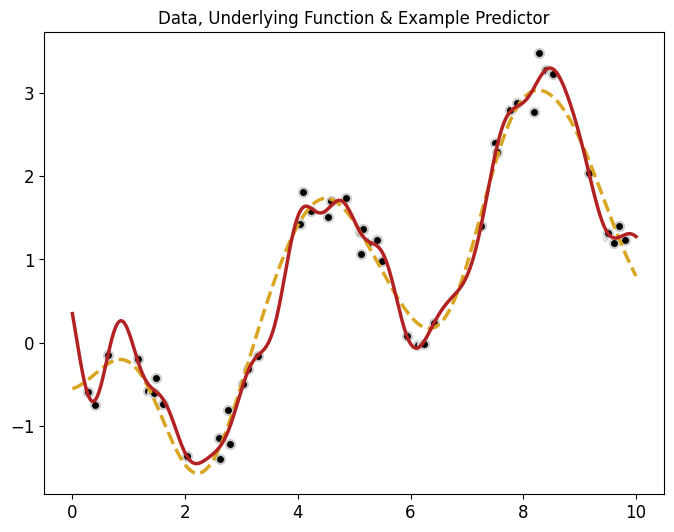

In [4]:
# Generate training data
generator = setup.DataGenerator(r=radius_gen, noise=sigma)
x_train, y_train = generator.get_data('TRAIN', N_train)
x_test, y_test = generator.get_data('TEST', N_test)

# Demonstrate use of basis
centres = np.linspace(generator.x_min, generator.x_max, N_train - 1)
radius_model = radius_gen * 0.5  # Example model uses basis functions that are too narrow
RBF = setup.RBFGenerator(centres, radius_model, bias=True)
PHI_train = RBF.evaluate(x_train)
PHI_test = RBF.evaluate(x_test)

# Find quick fit for fixed guess for alpha and known s2
alph = 1e-3
w_pls = np.linalg.inv(PHI_train.T @ PHI_train + alph * np.eye(RBF.M)) @ PHI_train.T @ y_train
fy_test = PHI_test @ w_pls

# Show the training data and generating function, plus our mean fit
setup.plot_regression(x_train, y_train, x_test, y_test, fy_test)
plt.title("Data, Underlying Function & Example Predictor");

## Inference Objective

The main goal is to estimate a useful value of the RBF width $r$ from the training data. In a fully Bayesian treatment, predictions would average over the complete posterior of $r$. Here, posterior expectations and samples provide practical approximations that also expose how proposal design affects computation.

The model is linear in its weights but nonlinear in $r$, because changing $r$ changes the design matrix. The weight and noise parameters can therefore be integrated out analytically in some calculations, while Monte Carlo methods handle the remaining parameter uncertainty.

# 1. Hyperparameter Posterior

The first experiment maps the posterior over prior precision $\alpha$ and RBF width $r$, assuming the noise variance $\sigma^2=0.2^2$ is known. The posterior is evaluated on a logarithmic parameter grid so that both small and large scales can be compared.

### Define The Hyperparameter Posterior

Bayes' rule gives

$$p(\alpha,r\mid y) \propto p(y\mid\alpha,r)p(\alpha)p(r).$$

Using uniform priors on the logarithms of the scale parameters makes the marginal likelihood the relevant unnormalised target. For every candidate $r$, the RBF design matrix is rebuilt before evaluating the log marginal likelihood. Working in log space keeps the calculation numerically stable and is convenient for sampling.

In [5]:
# Define the unnormalised hyperparameter log posterior

def log_prob_alph_r_given_y(alph, r, sigma_2, x, y, centres):
    RBF = setup.RBFGenerator(centres, r, bias=True)
    PHI_X = RBF.evaluate(x)

    return compute_log_marginal(PHI_X, y, alph, sigma_2)


### Explore The Posterior Surface

The posterior is evaluated over $\log_{10}\alpha\in[-6,4]$ and $\log_{10}r\in[-2,1]$. Plotting both the log posterior and its exponentiated form shows why logarithmic densities are more informative: the raw posterior concentrates most of its mass in a small region, while the log surface reveals its broader shape.

The maximum grid point gives a useful initial estimate for proposal distributions, but it is only a grid approximation rather than a full posterior summary.

In [6]:
# Evaluate the hyperparameter posterior over a logarithmic grid

# Define limits and sample steps
log10_alpha_lims = [-6, +4]
log10_r_lims = [-2, +1]
sample_steps = 100

# Create arrays with the ranges of values for alpha and r
log10_alpha_vals = np.linspace(log10_alpha_lims[0], log10_alpha_lims[1], sample_steps)
log10_r_vals = np.linspace(log10_r_lims[0], log10_r_lims[1], sample_steps)

# Change log values to normal
alpha_vals = 10 ** log10_alpha_vals
r_vals = 10 ** log10_r_vals

# Create the matrix to store log prob
log_prob = np.zeros((len(r_vals), len(alpha_vals)))

# Loop through values and store in matrix
for i, alph in enumerate(alpha_vals):
    for j, r in enumerate(r_vals):
        log_prob[i, j] = log_prob_alph_r_given_y(alph, r, sigma_2, x_train, y_train, centres)


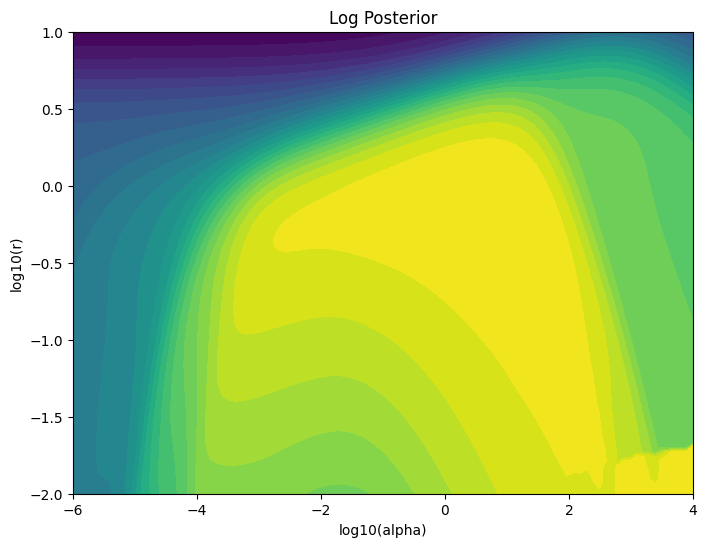

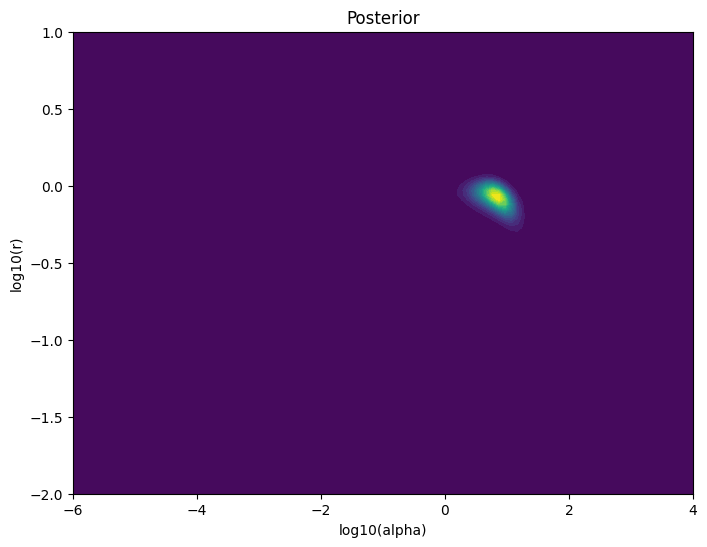

In [7]:
# Plot the log posterior
plt.figure(figsize=(8,6))
plt.contourf(log10_alpha_vals, log10_r_vals, log_prob, levels = 25)
plt.xlabel('log10(alpha)')
plt.ylabel('log10(r)')
plt.title('Log Posterior')
plt.show()

# Plot the posterior
plt.figure(figsize=(8,6))
plt.contourf(log10_alpha_vals, log10_r_vals, np.exp(log_prob), levels = 25)
plt.xlabel('log10(alpha)')
plt.ylabel('log10(r)')
plt.title('Posterior')
plt.show()


In [8]:
# Find the maximum of the hyperparameter posterior

# Find the index of the maximum values from log probability
max_index = np.unravel_index(np.argmax(log_prob), log_prob.shape)

# Use those index values to determine the max value
max_val = log_prob[max_index]

# Use those index to determine the max log10 for alpha and r
log10_alpha_max = log10_alpha_vals[max_index[0]]
log10_r_max = log10_r_vals[max_index[1]]

# Convert log10 to normal
alpha_max = 10 ** log10_alpha_max
r_max = 10 ** log10_r_max

# Define table
table_max_vals = [
    ["Maximum value of log p(alpha, r|y)", round(max_val, 5)],
    ["Most probable log alpha", round(log10_alpha_max, 5)],
    ["Most probable log r", round(log10_r_max, 5)],
    ["Most probable alpha", round(alpha_max, 5)],
    ["Most probable r", round(r_max, 5)]
]

# Set headers
headers_max_vals = ["Attributes", "Value"]

# Call tabulate_neatly
setup.tabulate_neatly(table_max_vals, headers_max_vals, title="Maximum of Hyperparameter Posterior")

Maximum of Hyperparameter Posterior

Attributes,Value
"Maximum value of log p(alpha, r|y)",-12.7223
Most probable log alpha,0.46465
Most probable log r,0.06061
Most probable alpha,2.91505
Most probable r,1.14976


# 2. Importance Sampling

Importance sampling estimates posterior expectations by drawing from a proposal distribution and reweighting each draw according to the ratio between target and proposal density. Here the quantity of interest is the posterior mean width,

$$\langle r\rangle = \int r\,p(\alpha,r\mid y)\,d\alpha\,dr.$$

The proposal is defined in $(\log_{10}\alpha,\log_{10}r)$ space, while the function being averaged converts the sampled width back to the original scale.

### Build The Importance Sampler

The sampler accepts four functions: an unnormalised target density, a proposal density, a proposal draw generator, and the function whose expectation is required. It maintains cumulative weighted sums and returns the running estimate after every sample, making convergence visible rather than reporting only the final number.

Three proposals are compared: a broad uniform distribution, a Gaussian centred in the search region, and a narrower Gaussian centred on the posterior maximum. A well-placed proposal should spend more samples where the posterior mass is concentrated and therefore produce a more stable estimate.

In [9]:
# Importance sampler function

def importance(num_samples, pstar, qstar, qrvs, fun):
    
    # Initialise the array
    expectations = np.zeros(num_samples)

    # Initilise cumulative variables
    c_weight = 0
    c_sum = 0

    for i in range(num_samples):
        # Generate a sample x (contains logAlpha and logR)
        x = qrvs()
        # Compute the weight of the sample
        weight = pstar(x) / qstar(x)
        # Update the cumulative sums
        c_weight += weight
        c_sum += fun(x) * weight


        # Calculate expectations
        # Add 1e-9 to ensure you don't divide by 0
        expectations[i] = c_sum / (c_weight + 1e-9)

    return expectations


### Compare Proposal Distributions

The three proposals are run with the same target and expectation function. Their running estimates of $\langle r\rangle$ are plotted together, allowing proposal efficiency and convergence behaviour to be compared directly.

### Reproducible Sampling

Sampling results depend on random draws, so each experiment uses an explicit random seed. Reproducible seeds make it possible to distinguish changes in proposal quality from ordinary Monte Carlo variation.

In [10]:
# Test the importance sampler

# For each of the three different proposal distributions:
# - chart the convergence of the expectation
# - print out the final expectation <r>

num_samples = 5000 

rng = np.random.default_rng(42)

# Define pstar
pstar = lambda x: np.exp(log_prob_alph_r_given_y(10**x[0], 10**x[1], sigma_2, x_train, y_train, centres))

# Define fun
fun = lambda x: 10**x[1]


# Define variables to be usd in qstar and qrvs

log_alpha_min = log10_alpha_lims[0]
log_r_min = log10_r_lims[0]

log_alpha_scale = log10_alpha_lims[1] - log10_alpha_lims[0]
log_r_scale = log10_r_lims[1] - log10_r_lims[0]

log_mid = np.array([(log10_alpha_lims[1] + log10_alpha_lims[0] / 2), (log10_r_lims[1] + log10_r_lims[0] / 2) ])
log_best_max = np.array([log10_alpha_max, log10_r_max])

log_alpha_mid_std = log_alpha_scale / 6
log_r_mid_std = log_r_scale / 6

log_alpha_max_std = log_alpha_scale / 10
log_r_max_std = log_r_scale / 10

cov_mid = np.diag([log_alpha_mid_std**2, log_r_mid_std**2])
cov_max = np.diag([log_alpha_max_std**2, log_r_max_std**2])


# Define qstar functions for uniform, gaussian middle and gaussian max

def qstar_uni(x):
    log_alpha, log_r = x  
    log_alpha_d = stats.uniform.pdf(log_alpha, loc=log_alpha_min, scale=log_alpha_scale)                     
    log_r_d = stats.uniform.pdf(log_r, loc=log_r_min, scale=log_r_scale)
    return log_alpha_d * log_r_d

def qstar_gaus_mid(x):
    return stats.multivariate_normal.pdf(x, mean=log_mid, cov=cov_mid)


def qstar_gaus_max(x):
    return stats.multivariate_normal.pdf(x, mean=log_best_max, cov=cov_max)


# Define qrvs functions for uniform, gaussian middle and gaussian max

def qrvs_uni():
    log_alpha = stats.uniform.rvs(loc = log_alpha_min, scale = log_alpha_scale)
    log_r = stats.uniform.rvs(loc = log_r_min, scale = log_r_scale, random_state=rng)
    return np.array([log_alpha, log_r])

def qrvs_gaus_mid():
    return stats.multivariate_normal.rvs(log_mid, cov_mid, random_state=rng)


def qrvs_gaus_max():
    return stats.multivariate_normal.rvs(log_best_max, cov_max, random_state=rng)


# Calculate expectations for uniform, gaussian middle and gaussian max

expectations_uniform = importance(num_samples, pstar, qstar_uni, qrvs_uni, fun)
expectations_gaus_mid = importance(num_samples, pstar, qstar_gaus_mid, qrvs_gaus_mid, fun)
expectations_gaus_max = importance(num_samples, pstar, qstar_gaus_max, qrvs_gaus_max, fun)

# Define table
table_expectation = [
    ["Uniform", round(expectations_uniform[-1], 5)],
    ["Gaussian Midpoint", round(expectations_gaus_mid[-1], 5)],
    ["Guassian Maximum", round(expectations_gaus_max[-1], 5)],
]

# Set headers
headers_expectation = ["Proposal", "Expected value of r"]

# Call tabulate_neatly
setup.tabulate_neatly(table_expectation, headers_expectation, title="Final expected value of r")




Final expected value of r

Proposal,Expected value of r
Uniform,1.11155
Gaussian Midpoint,1.09779
Guassian Maximum,1.10949


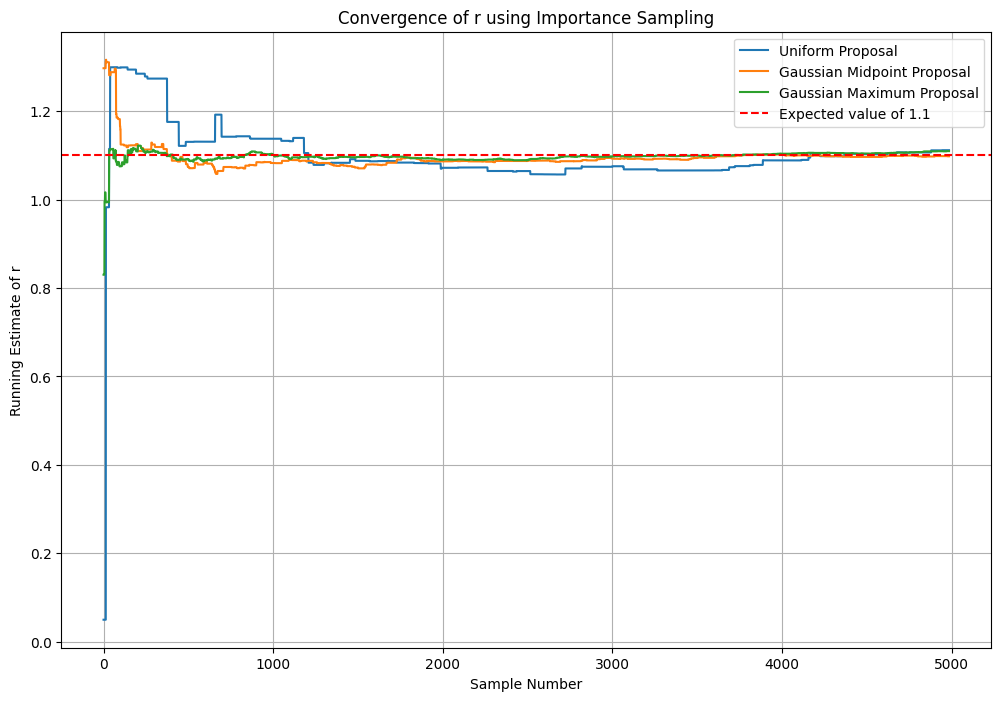

In [11]:
# Plot convergence for the three importance proposals

# Trim to remove the first 15 high variance values
trim = 15

# Plot the convergence
plt.figure(figsize=(12, 8))
plt.plot(expectations_uniform[trim:], label="Uniform Proposal")
plt.plot(expectations_gaus_mid[trim:], label="Gaussian Midpoint Proposal")
plt.plot(expectations_gaus_max[trim:], label="Gaussian Maximum Proposal")
plt.axhline(y=1.1, ls = '--', c = 'red', label = "Expected value of 1.1")
plt.xlabel("Sample Number")
plt.ylabel("Running Estimate of r")
plt.title("Convergence of r using Importance Sampling")
plt.legend()
plt.grid(True)
plt.show()


### Estimate Monte Carlo Variance

A single convergence trace can be misleading. This experiment repeats the importance sampler with different seeds and estimates the variance of the running expectation at each sample index. Falling variance indicates that the estimates are becoming more stable; comparing the three curves reveals how proposal concentration affects efficiency.

In [12]:
# Compare importance-sampling variance across repeated runs

# Output should be a graph showing the variance of the Expectations
# against sample number, as computed over multiple repetitions,
# with all three proposals on the same axis.


def importance_sampler_variance(num_samples, num_seeds):
    # Create a list of seeds
    seeds = range(num_seeds)

    # Define how we will store the variables
    uniform_res = []
    gaus_mid_res = []
    gaus_max_res = []

    # Iterate through the different seeds
    for seed in seeds:
        # Set the seed
        rng = np.random.default_rng(seed)
        # Add expected values of r for each proposal to their arrays
        uniform_res.append(importance(num_samples, pstar, qstar_uni, qrvs_uni, fun))
        gaus_mid_res.append(importance(num_samples, pstar, qstar_gaus_mid, qrvs_gaus_mid, fun))
        gaus_max_res.append(importance(num_samples, pstar, qstar_gaus_max, qrvs_gaus_max, fun))
    
    # Calculate the variance in each proposal
    uniform_var = np.var(uniform_res, axis=0)
    gaus_mid_var = np.var(gaus_mid_res, axis=0)
    gaus_max_var = np.var(gaus_max_res, axis=0)

    return uniform_var, gaus_mid_var, gaus_max_var


# Call our importance sampler variance function and store the results
uniform_var, gaus_mid_var, gaus_max_var = importance_sampler_variance(2000,100)

    



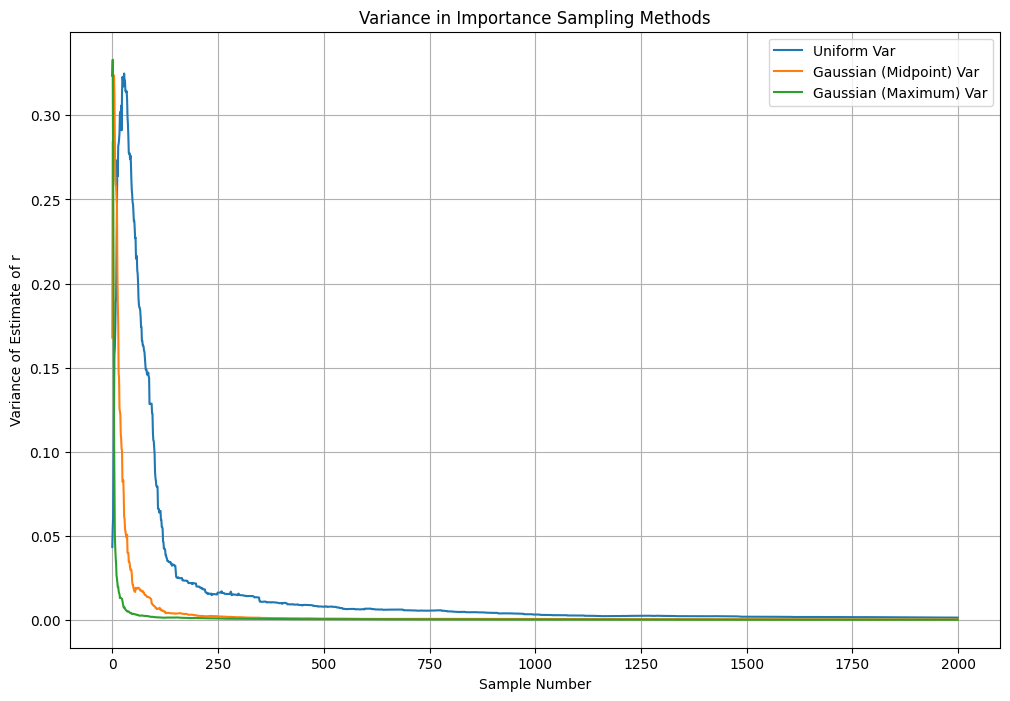

In [13]:
# Plot the variance of each proposal at different sample steps
plt.figure(figsize=(12, 8))
plt.plot(uniform_var, label="Uniform Var")
plt.plot(gaus_mid_var, label="Gaussian (Midpoint) Var")
plt.plot(gaus_max_var, label="Gaussian (Maximum) Var")
plt.xlabel("Sample Number")
plt.ylabel("Variance of Estimate of r")
plt.title("Variance in Importance Sampling Methods")
plt.legend()
plt.grid(True)
plt.show()


# 3. Metropolis MCMC

Importance sampling can become inefficient when the proposal misses a concentrated target. Metropolis MCMC takes local proposals from the current state and accepts or rejects them using the target-density ratio. The resulting chain can explore the posterior without requiring a proposal that covers the entire space efficiently.

### Implement The Metropolis Chain

Each proposal is generated from a Gaussian centred on the current state. Accepted proposals move the chain; rejected proposals repeat the current state. The notebook records both arrays so that the sampled path and rejected proposals can be inspected together.

The proposal scale controls the trade-off: very small steps are usually accepted but explore slowly, while very large steps move farther but are often rejected. The following experiments compare narrow, broad, and tuned scales using acceptance rates and diagnostic plots.

In [14]:
# Metropolis algorithm implementation

def metropolis(num_samples, pstar, qrvs, x0):
    # Initialise our array of samples with x0
    samples = [x0]
    # Initialise our rejected samples array
    rejected = []
    # Set the initial position
    curX = x0

    # Iterate over the number of samples
    for i in range(num_samples):
        # Calculate proposal theta prime
        xdash = qrvs(curX)
        # Calculate the probablity of theta prime
        pTheta = pstar(xdash)
        # Calculate the probabillty of theta t
        pThetaT = pstar(curX)
        # Compute threshold kappa
        kappa = pTheta / pThetaT
        # If kappa is greater than 1, or else with probablity kappa
        if kappa >= np.random.uniform(0,1):
            # Accept the proposed sample
            samples.append(xdash)
            # Update the current sample
            curX = xdash
        else:
            # Reject the sample
            samples.append(curX)
            rejected.append(xdash) 
    # Return the sample and rejected arrays
    return np.array(samples), np.array(rejected)



### Diagnose Mixing And Convergence

The Metropolis chain is used to estimate $\langle r\rangle$ again. The first part of each chain is treated as burn-in, then running averages and histograms show whether the proposals explore a consistent posterior region.

The narrow, broad, and tuned proposals illustrate different failure modes. Acceptance rate alone is not enough: a chain can accept almost everything while making very little progress, or accept too little to explore the target effectively.

In [15]:
# Compare Metropolis proposals for estimating the posterior mean of r

# Define our random seed
rng = np.random.default_rng(42)

# Set our scales for the narrow, broad and right proposals
narrow_scale = 0.02
broad_scale = 0.65
right_scale = 0.20

# Calculate the covariance matrices for these proposals
cov_narrow = np.diag([narrow_scale**2, narrow_scale**2])
cov_broad = np.diag([broad_scale**2, broad_scale**2])
cov_right = np.diag([right_scale**2, right_scale**2])

# Define number of samples
num_samples = 10000

# # Define our starting value of x0 as a random value within the range of log alpha and r values
# x0 = np.array([rng.uniform(log10_alpha_lims[0], log10_alpha_lims[1]),
#                rng.uniform(log10_r_lims[0], log10_r_lims[1])])

# Define x0 as a deliberately badly initial value
x0 = np.array([-4, -1.5])
               

# Define our new qvrs functions

def qvrs_metro_narrow(x):
    return stats.multivariate_normal.rvs(x, cov_narrow, random_state=rng)

def qvrs_metro_broad(x):
    return stats.multivariate_normal.rvs(x, cov_broad, random_state=rng)

def qvrs_metro_right(x):
    return stats.multivariate_normal.rvs(x, cov_right, random_state=rng)


# Sample from the posterior
narrow_samples, narrow_rejected = metropolis(num_samples, pstar, qvrs_metro_narrow, x0)
broad_samples, broad_rejected = metropolis(num_samples, pstar, qvrs_metro_broad, x0)
right_samples, right_rejected = metropolis(num_samples, pstar, qvrs_metro_right, x0)

# Set our burn in value
burn_in = int(0.05 * num_samples)

# Select and transform r values from each proposal (minus the burn in)
r_values_narrow = 10 ** (narrow_samples[burn_in:, 1])
r_values_broad = 10 ** (broad_samples[burn_in:, 1])
r_values_right = 10 ** (right_samples[burn_in:, 1])

# Compute running average:
running_avg_narrow = np.cumsum(r_values_narrow) / np.arange(1, len(r_values_narrow) + 1)
running_avg_broad = np.cumsum(r_values_broad) / np.arange(1, len(r_values_broad) + 1)
running_avg_right = np.cumsum(r_values_right) / np.arange(1, len(r_values_right) + 1)

# Calculate acceptance rate for each proposal
narrow_acc_rate = (num_samples - len(narrow_rejected)) / num_samples
broad_acc_rate = (num_samples - len(broad_rejected)) / num_samples
right_acc_rate = (num_samples - len(right_rejected)) / num_samples

# Define table
table_metro = [
    ["Narrow", narrow_scale, round(running_avg_narrow[-1], 5), round(narrow_acc_rate * 100, 2)],
    ["Broad", broad_scale, round(running_avg_broad[-1], 5), round(broad_acc_rate * 100, 2)],
    ["Right", right_scale, round(running_avg_right[-1], 5), round(right_acc_rate * 100, 2)],
]

# Set headers
headers_metro = ["Proposal", "Scale Value", "Final value of r", "Acceptance Rate (%)"]

# Call tabulate_neatly
setup.tabulate_neatly(table_metro, headers_metro, title="Metropolis Sampler with Narrow, Broad and Right Proposals")

Metropolis Sampler with Narrow, Broad and Right Proposals

Proposal,Scale Value,Final value of r,Acceptance Rate (%)
Narrow,0.02,1.05939,84.26
Broad,0.65,1.10723,4.99
Right,0.2,1.11923,27.81


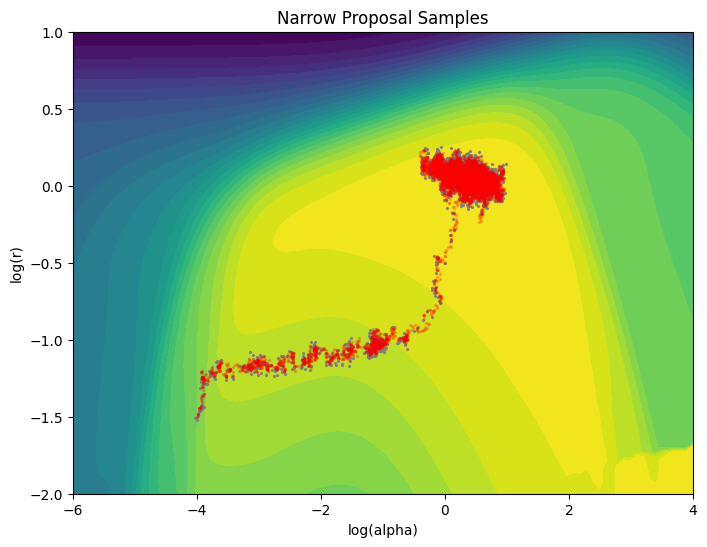

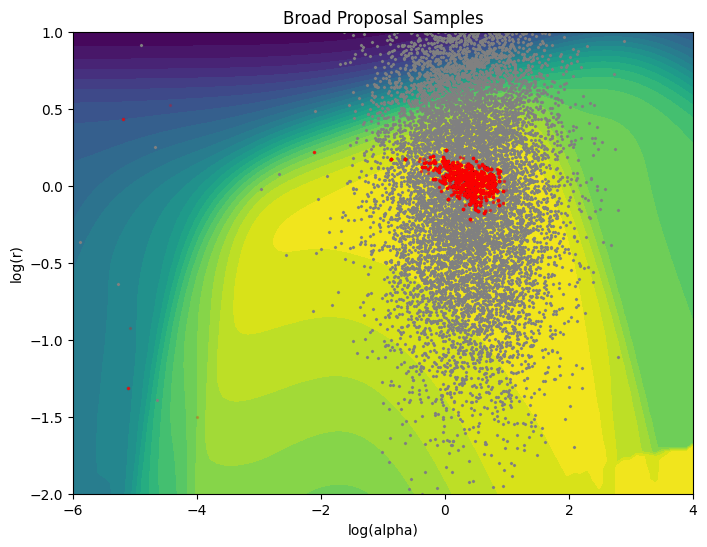

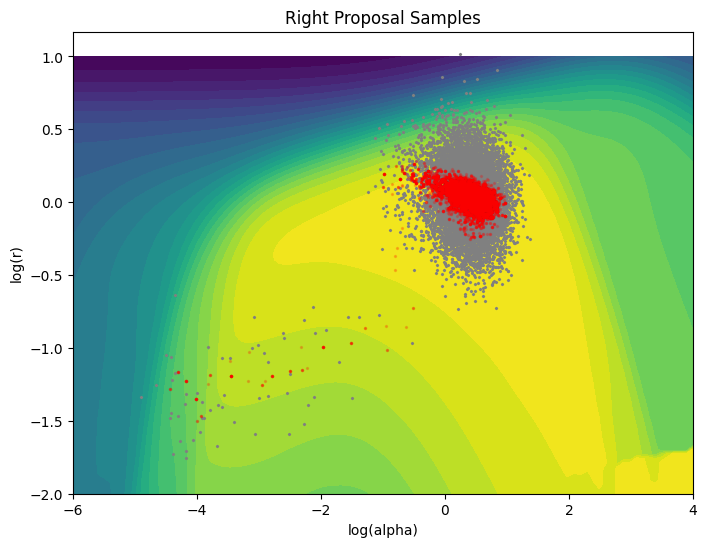

In [16]:
# Visualise the samples

# Plot the different proposals

plt.figure(figsize=(8,6))
plt.contourf(log10_alpha_vals, log10_r_vals, log_prob, levels = 25)
plt.scatter(narrow_rejected[:, 0], narrow_rejected[:, 1], color='gray', marker='x', s=2, label='Rejected Proposals')
plt.scatter(narrow_samples[:, 0], narrow_samples[:, 1], color='red', marker='o', s=2, alpha=0.2, label='Accepted Samples')
plt.xlabel('log(alpha)')
plt.ylabel('log(r)')
plt.title('Narrow Proposal Samples')
plt.show()


plt.figure(figsize=(8,6))
plt.contourf(log10_alpha_vals, log10_r_vals, log_prob, levels = 25)
plt.scatter(broad_rejected[:, 0], broad_rejected[:, 1], color='gray', marker='x', s=2, label='Rejected Proposals')
plt.scatter(broad_samples[:, 0], broad_samples[:, 1], color='red', marker='o', s=2, alpha=0.2, label='Accepted Samples')
# Fix the axis as some rejected proposals go outside the limits of log alpha and r
plt.ylim(-2, 1)
plt.xlim(-6, 4)
plt.xlabel('log(alpha)')
plt.ylabel('log(r)')
plt.title('Broad Proposal Samples')
plt.show()

plt.figure(figsize=(8,6))
plt.contourf(log10_alpha_vals, log10_r_vals, log_prob, levels = 25)
plt.scatter(right_rejected[:, 0], right_rejected[:, 1], color='gray', marker='x', s=2, label='Rejected Proposals')
plt.scatter(right_samples[:, 0], right_samples[:, 1], color='red', marker='o', s=2, alpha=0.2, label='Accepted Samples')
plt.xlabel('log(alpha)')
plt.ylabel('log(r)')
plt.title('Right Proposal Samples')
plt.show()

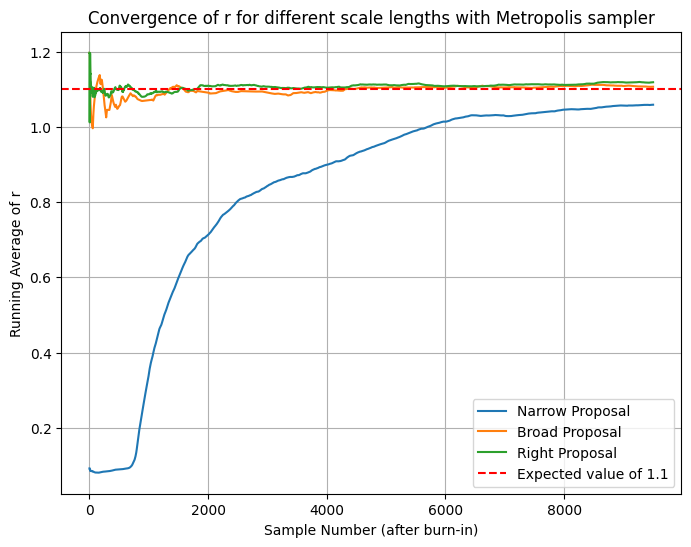

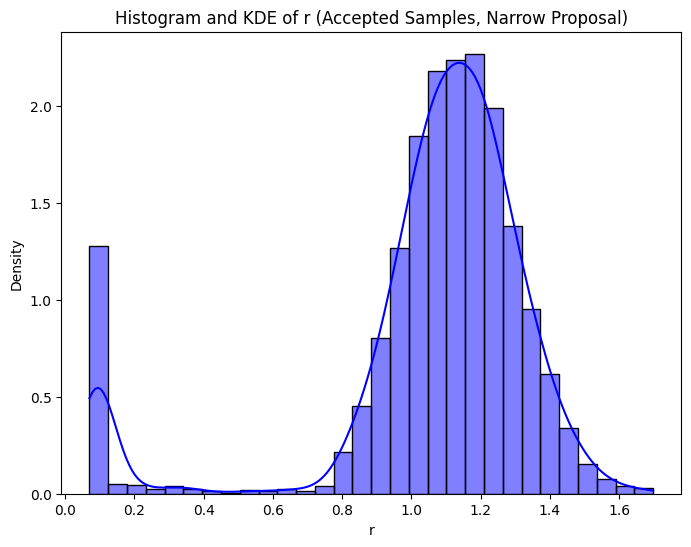

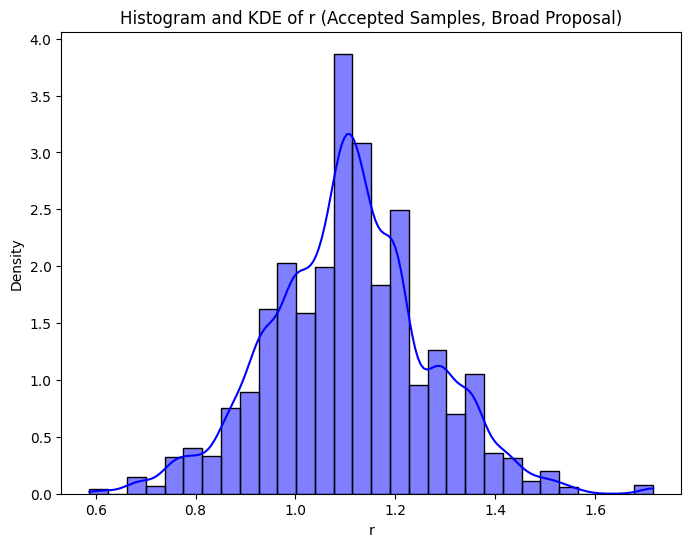

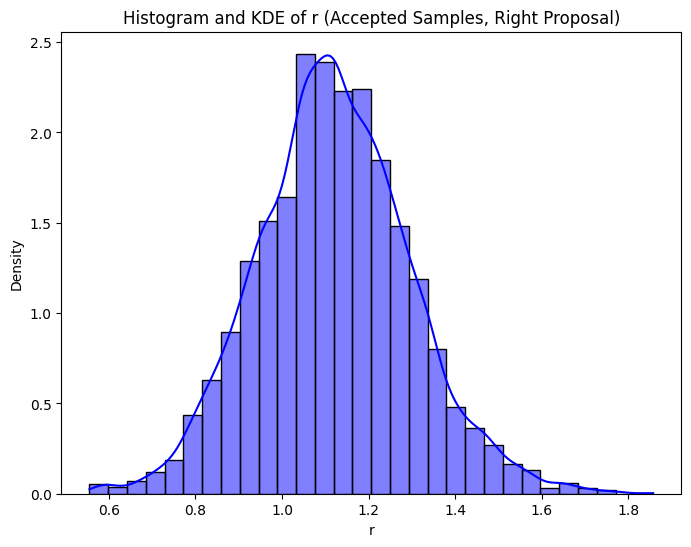

In [17]:
# Plot some diagnostics
import seaborn as sns

# Plot the convergence of the r estimate
plt.figure(figsize=(8, 6))
plt.plot(running_avg_narrow, label = "Narrow Proposal")
plt.plot(running_avg_broad, label = "Broad Proposal")
plt.plot(running_avg_right, label = "Right Proposal")
plt.axhline(y=1.1, ls = '--', c = 'red', label = "Expected value of 1.1")
plt.xlabel('Sample Number (after burn-in)')
plt.ylabel('Running Average of r')
plt.title('Convergence of r for different scale lengths with Metropolis sampler')
plt.legend()
plt.grid(True)
plt.show()


# Plot the histograms 

plt.figure(figsize=(8, 6))
sns.histplot(r_values_narrow, bins=30, kde=True, stat="density", color='blue')
plt.xlabel('r')
plt.ylabel('Density')
plt.title('Histogram and KDE of r (Accepted Samples, Narrow Proposal)')
plt.show()


plt.figure(figsize=(8, 6))
sns.histplot(r_values_broad, bins=30, kde=True, stat="density", color='blue')
plt.xlabel('r')
plt.ylabel('Density')
plt.title('Histogram and KDE of r (Accepted Samples, Broad Proposal)')
plt.show()


plt.figure(figsize=(8, 6))
sns.histplot(r_values_right, bins=30, kde=True, stat="density", color='blue')
plt.xlabel('r')
plt.ylabel('Density')
plt.title('Histogram and KDE of r (Accepted Samples, Right Proposal)')
plt.show()

### Infer The Noise Scale

The sampler is extended with a third state variable, $\log_{10}\sigma$. The posterior now reflects uncertainty in the observation noise as well as $\alpha$ and $r$. A convergence trace and posterior histogram provide a check that the inferred noise scale is consistent with the data-generating value.

In [18]:
# Extend the Metropolis sampler to estimate the noise std dev

# Set our random seed
rng = np.random.default_rng(42)

# Extend pstar to include sigma
pstar_sigma = lambda x: np.exp(log_prob_alph_r_given_y(10**x[0], 10**x[1], (10 ** x[2]) ** 2, x_train, y_train, centres))

just_right_scale = 0.25

# Calculate new cov matrix including dimension for sigma
cov_right_sigma = np.diag([just_right_scale**2, just_right_scale**2, just_right_scale**2])

# Define our new qrvs functions
def qrvs_metro_sigma(x):
    return stats.multivariate_normal.rvs(mean=x, cov=cov_right_sigma, random_state=rng)

# Set limits on log values for sigma
log10_sigma_lims = [-1, 1]

# Define our starting value of x0 as a random value within the range of log alpha, r and sigma values
x0_sigma = np.array([rng.uniform(log10_alpha_lims[0], log10_alpha_lims[1]),
               rng.uniform(log10_r_lims[0], log10_r_lims[1]),
               rng.uniform(log10_sigma_lims[0], log10_sigma_lims[1])])

# Define our number of samples
num_samples = 10000

# Sample from the posterior
sigma_samples, sigma_rejected = metropolis(num_samples, pstar_sigma, qrvs_metro_sigma, x0_sigma)

# Define our burn_in
burn_in = int(0.05 * num_samples)

# Extract log sigma values
log_sigma_samples = sigma_samples[burn_in:, 2]

# Convert to sigma
sigma_samples = 10 ** log_sigma_samples


# Compute running average for convergence diagnostics
running_avg_sigma = np.cumsum(sigma_samples) / np.arange(1, len(sigma_samples)+1)

print("Final expected value of sigma:", running_avg_sigma[-1])







Final expected value of sigma: 0.1901995616793773


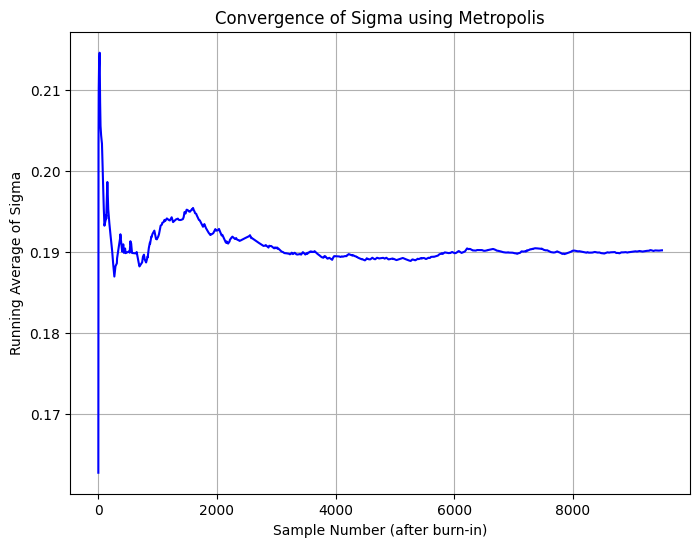

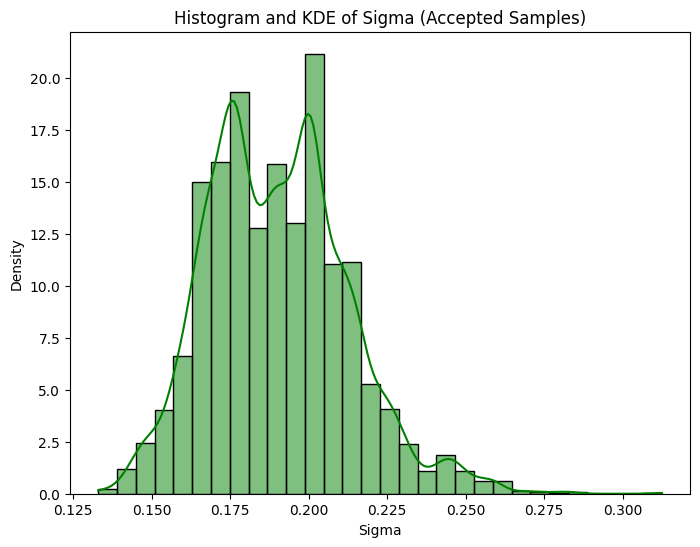

In [19]:
# Plot convergence
plt.figure(figsize=(8,6))
plt.plot(running_avg_sigma, color='blue')
plt.xlabel('Sample Number (after burn-in)')
plt.ylabel('Running Average of Sigma')
plt.title('Convergence of Sigma using Metropolis')
plt.grid(True)
plt.show()


# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(sigma_samples, bins=30, kde=True, stat="density", color='green')
plt.xlabel('Sigma')
plt.ylabel('Density')
plt.title('Histogram and KDE of Sigma (Accepted Samples)')
plt.show()

### Joint Sampling Of All Unknowns

The final extension samples the weights together with $\alpha$, $r$, and $\sigma$. This produces a 53-dimensional state for the current model: 50 weights plus three hyperparameters.

Although the weight posterior can be computed analytically for this linear model, joint Metropolis sampling demonstrates a pattern that generalises to nonlinear models where analytic marginalisation is unavailable. Each sampled state generates a test-grid prediction; averaging those predictions gives a fully Bayesian mean predictor.

In [20]:
# Extend the Metropolis sampler to model all unknowns and plot a mean predictor


In [21]:
# Plot the mean predictor and output the noise estimate
